## Data Cleaning First Project

In [1]:
#Import all the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#remove Warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# read and upload the dataset
df= pd.read_csv("dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


## Columns Description
Transaction ID	:- A unique identifier for each transaction. Always present and unique.

Item   :- The name of the item purchased. 

Quantity :- The quantity of the item purchased. 

Price Per Unit :- The price of a single unit of the item. 

Total Spent :- The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.

Payment Method:- The method of payment used. 
Location  :- The location where the transaction occurred. 
Transaction Date :- The date of the transaction. 

In [5]:
#shows top 5 rows by default
df.head()   # default 5 rows
df.head(10)  # showing 10 rows 

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [6]:
#shows bottom 5 rows by default
df.tail()   # Default 5 rows
df.tail(10)  # showing 10 rows

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9990,TXN_1538510,Coffee,5,2.0,10.0,Digital Wallet,NaN,2023-05-22
9991,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24
9992,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-07-05
9993,TXN_4766549,Smoothie,2,4.0,NaN,Cash,NaN,2023-10-20
9994,TXN_7851634,UNKNOWN,4,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [7]:
#  it return (number of rows, number of columns)
df.shape

(10000, 8)

In [8]:
''' The DataFrame.info() method in pandas prints a concise(giving a lot of information in a few words; brief) 
summary of a DataFrame, providing a quick "health check" of your dataset's structure.

'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [9]:
''' it gives statistical summary for numerical columns:
'''
df.describe()
#df.describe(include = "object")  # object is a String.

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [10]:
#finding total count of null values in a dataset
df.isnull()
df.notnull()
#df.isnull().sum() %len(df)/100   # calculate the percentage of null values
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [11]:
# to check the unique values
print(df['Transaction ID'].is_unique)
print(df['Transaction ID'].duplicated().sum())

True
0


In [12]:
# check the total items from Dataset
df["Item"].value_counts(dropna=False)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

In [13]:
# drop all the Error values in a Item Column
df["Item"]
df = df[df["Item"] != "ERROR"]

In [14]:
# check Error values drop
df["Item"].value_counts(dropna = False)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
Name: count, dtype: int64

In [15]:
# replace the Unknown to NaN value in a column because of Unknown and NaN value is a same.
df["Item"] = df["Item"].replace(["UNKNOWN"],np.nan)
df["Item"].value_counts(dropna = False)


Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
NaN          677
Name: count, dtype: int64

In [16]:
df["Item"].isnull().sum()

np.int64(677)

In [17]:
#find the mode value in Item Column (Item column contain a categorical data)
item_mode_value= df["Item"].mode()[0]
print(item_mode_value)

# fill the mode value in a Item and replace the nan to mode 
df["Item"] = df["Item"].fillna(item_mode_value)

Juice


In [40]:
# find the Numerical column Data 
#(Quantity , price per unit, total spent)  ------------> convert it into int
print(df.select_dtypes(include="number").columns.tolist())
print(df["Quantity"].dtype)
# find the total count of Quantity
df["Quantity"].value_counts(dropna = False)

['Quantity', 'Price Per Unit', 'Total Spent', 'Price Per unit']
float64


Quantity
5.00000    1950
2.00000    1916
4.00000    1812
3.00000    1795
1.00000    1774
3.02682     461
Name: count, dtype: int64

In [19]:
# replace the Unknown and Error value in a column
df["Quantity"] = df["Quantity"].replace(["UNKNOWN", "ERROR"],np.nan)

In [20]:
# checking the Null values
df["Quantity"].isnull().sum()

np.int64(461)

In [21]:
print(df.select_dtypes(include="number").columns.tolist())   # check numerical column
df["Quantity"] = pd.to_numeric(df["Quantity"],errors="coerce").astype("float")  #(errors="coerce") :It converts any invalid value into NaN.

[]


In [22]:
df["Quantity"].describe()

count    9247.000000
mean        3.026820
std         1.418999
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

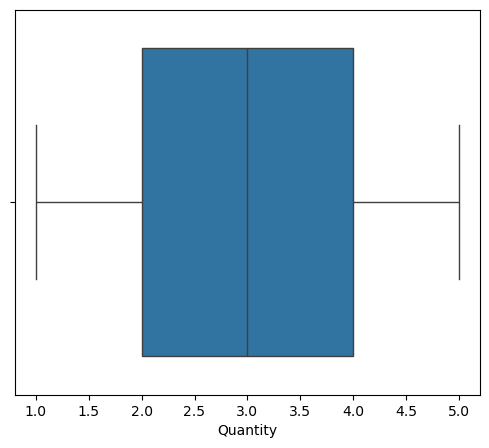

In [23]:
# In Quantity column there is no Outlier
plt.figure(figsize=(6, 5))
sns.boxplot(x=df["Quantity"])
plt.show()

In [97]:
# finding the Mean and Median value in a quantity
mean_value = df["Quantity"].mean()   # The data forms a symmetric bell curve without extreme values.
median_value = df["Quantity"].median()   # The data is pulled to one side (left or right tail).
print(mean_value)
print(median_value)

# fill the mean value in a Quantity column bacause there are no outliear and no data flow to left and right side.
df["Quantity"] = df["Quantity"].fillna(mean_value)

3.0268195090299552
3.0


In [98]:
# checking the Null values
df["Quantity"].isnull().sum()

np.int64(0)

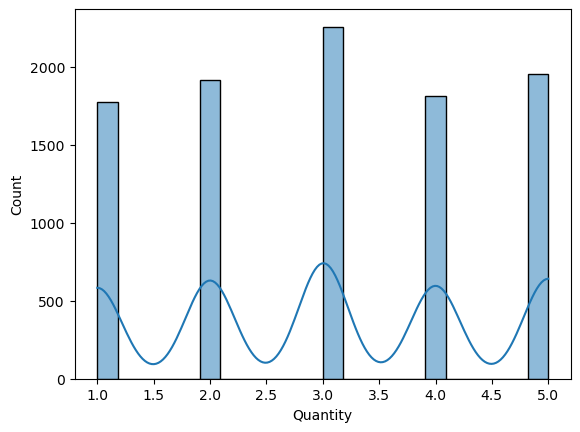

In [99]:
sns.histplot(data=df, x='Quantity', kde=True)
plt.show()

In [100]:
df["Quantity"].value_counts()

Quantity
5.00000    1950
2.00000    1916
4.00000    1812
3.00000    1795
1.00000    1774
3.02682     461
Name: count, dtype: int64

In [101]:
# find The categorical column Data (Transaction ID, Item,Payment Method, Location,Transaction Date)
print(df.select_dtypes(include="object").columns.tolist())

['Transaction ID', 'Item', 'Payment Method', 'Location']


In [102]:
df["Item"].value_counts()    # single column
# check all the total column values
for i in df.columns.tolist():
    print(df[i].value_counts(dropna=False))
    print()

Transaction ID
TXN_1961373    1
TXN_7894069    1
TXN_2522047    1
TXN_8211303    1
TXN_8472252    1
              ..
TXN_4151440    1
TXN_7921799    1
TXN_1715317    1
TXN_2482242    1
TXN_6170729    1
Name: count, Length: 9708, dtype: int64

Item
Juice       1848
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

Quantity
5.00000    1950
2.00000    1916
4.00000    1812
3.00000    1795
1.00000    1774
3.02682     461
Name: count, dtype: int64

Price Per Unit
3.0    2352
4.0    2270
2.0    1196
5.0    1165
1.0    1109
1.5    1096
NaN     520
Name: count, dtype: int64

Total Spent
6.000000     896
12.000000    871
4.000000     856
3.000000     853
20.000000    691
15.000000    671
8.000000     643
NaN          520
10.000000    480
2.000000     449
9.000000     449
5.000000     423
16.000000    412
25.000000    231
1.000000     217
7.500000     213
4.500000     208
1.500000     181
12.107278    

In [128]:
# converting Categorical to Numerical
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"],errors="coerce").astype("float")

In [129]:
# Price Per Unit 
#print(df["Price Per Unit"].isnull().sum())
mean_value = df["Price Per Unit"].mean() 
print(mean_value)
df["Price Per Unit"]= df["Price Per Unit"].fillna(mean_value,inplace = False)


2.950152372659992


In [130]:
df["Price Per Unit"].isnull().sum()

np.int64(0)

In [131]:
df["Price Per Unit"].value_counts(dropna=False)

Price Per Unit
3.000000    2352
4.000000    2270
2.000000    1196
5.000000    1165
1.000000    1109
1.500000    1096
2.950152     520
Name: count, dtype: int64

In [132]:
# total spent column multipy by Quantity and Price Per Unit
# change null,unknown and error value to 0
df['Total Spent'] = df['Total Spent'].fillna(0)   # for null values   


In [133]:
df['Total Spent'] = df['Total Spent'].replace(['UNKNOWN','ERROR'], 0)   # for unknown and error values

In [134]:
df["Total Spent"].value_counts()   # total 0 is 485 because we replace nan,unknown,error value to 0

Total Spent
6.000000     896
12.000000    871
4.000000     856
3.000000     853
20.000000    691
15.000000    671
8.000000     643
0.000000     520
10.000000    480
2.000000     449
9.000000     449
5.000000     423
16.000000    412
25.000000    231
1.000000     217
7.500000     213
4.500000     208
1.500000     181
12.107278    114
9.080459      95
6.053639      69
4.540229      57
15.134098     56
3.026820      53
Name: count, dtype: int64

In [135]:
df["Total Spent"].isnull().sum()

np.int64(0)

In [136]:
# to check Total spent column data type and convert it float
#df["Total Spent"].astype
df["Total Spent"] = pd.to_numeric(df["Total Spent"],errors="coerce").astype("float")

df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [137]:
# multipy two columns
df["Total Spent"] = (df["Quantity"]) * (df["Price Per Unit"])

In [138]:
#df["Total Spent"].tail(20)
df[['Quantity', 'Price Per Unit','Total Spent']]

,Quantity,Price Per Unit,Total Spent
0,2.0,2.000000,4.000000
1,4.0,3.000000,12.000000
2,4.0,1.000000,4.000000
3,2.0,5.000000,10.000000
4,2.0,2.000000,4.000000
...,...,...,...
9995,2.0,2.000000,4.000000
9996,3.0,2.950152,8.850457
9997,4.0,2.000000,8.000000
9998,3.0,2.950152,8.850457


In [139]:
df["Total Spent"].isnull().sum()

np.int64(0)

In [140]:
#Returns column names
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [141]:
#Returns row labels (index)
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9990, 9991, 9992, 9993, 9994, 9995, 9996, 9997, 9998, 9999],
      dtype='int64', length=9708)

In [142]:
# find the data type of each column
df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [143]:
# access single column
df["Item"]      # single bracket means Series

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996       Juice
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 9708, dtype: object

In [144]:
# access Multiple column
df[["Item","Quantity","Location"]]   # double brackets is a Dictionary

,Item,Quantity,Location
0,Coffee,2.0,Takeaway
1,Cake,4.0,In-store
2,Cookie,4.0,In-store
3,Salad,2.0,UNKNOWN
4,Coffee,2.0,In-store
...,...,...,...
9995,Coffee,2.0,UNKNOWN
9996,Juice,3.0,Takeaway
9997,Coffee,4.0,Takeaway
9998,Cookie,3.0,Takeaway


In [145]:
# sort the Transaction Date
df.sort_values(by = "Transaction Date",ascending = True).head(20)  # single column

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1806,TXN_2192787,Sandwich,5.00000,4.000000,20.000000,Cash,In-store,2023-01-01
9063,TXN_9161256,Smoothie,2.00000,4.000000,8.000000,Digital Wallet,In-store,2023-01-01
1912,TXN_5563675,Tea,3.00000,1.500000,4.500000,Digital Wallet,In-store,2023-01-01
8015,TXN_4801947,Juice,1.00000,3.000000,3.000000,Digital Wallet,Takeaway,2023-01-01
2072,TXN_8308672,Salad,2.00000,5.000000,10.000000,Digital Wallet,Takeaway,2023-01-01
4285,TXN_4292280,Cake,4.00000,3.000000,12.000000,Cash,Takeaway,2023-01-01
8885,TXN_1581562,Coffee,2.00000,2.000000,4.000000,Cash,In-store,2023-01-01
1777,TXN_7367474,Juice,5.00000,3.000000,15.000000,Digital Wallet,Takeaway,2023-01-01
2244,TXN_5358805,Coffee,5.00000,2.000000,10.000000,Digital Wallet,Takeaway,2023-01-01
7152,TXN_6566716,Coffee,3.02682,2.000000,6.053639,Credit Card,Takeaway,2023-01-01


In [146]:
# count total number of items purchased
df["Item"].value_counts().sort_values(ascending = False)

Item
Juice       1848
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

In [147]:
# find The Duplicate Values:-
print(df.duplicated().sum())

0


In [148]:
# get the Original Column Data from dataset
df_original_col = pd.read_csv('dirty_cafe_sales.csv', usecols=['Payment Method'])
df['Payment Method'] = df_original_col['Payment Method']

In [149]:
df["Payment Method"].value_counts(dropna=False)
df["Payment Method"] = df["Payment Method"].replace("ERROR", np.nan)

In [150]:
df["Payment Method"].value_counts(dropna=False)
mode_value = df["Payment Method"].mode()[0]
df["Payment Method"] = df["Payment Method"].fillna(mode_value)


In [151]:
df["Payment Method"].value_counts(dropna=False)

Payment Method
Digital Wallet    5026
Credit Card       2201
Cash              2196
UNKNOWN            285
Name: count, dtype: int64

In [152]:
df["Payment Method"].isnull().sum()

np.int64(0)

In [153]:
df["Location"].value_counts(dropna=False)

Location
Takeaway    6452
In-store    2930
UNKNOWN      326
Name: count, dtype: int64

In [154]:
df["Location"] = df["Location"].replace("ERROR", np.nan)

In [155]:
df["Location"].value_counts(dropna=False)

Location
Takeaway    6452
In-store    2930
UNKNOWN      326
Name: count, dtype: int64

In [156]:
mode_value = df["Location"].mode()[0]
print(mode_value)
df["Location"] = df["Location"].fillna(mode_value)

Takeaway


In [157]:
df["Location"].value_counts(dropna=False)

Location
Takeaway    6452
In-store    2930
UNKNOWN      326
Name: count, dtype: int64

In [158]:
print(df["Transaction Date"].value_counts(dropna=False))

Transaction Date
NaT           451
2023-03-13     39
2023-07-24     39
2023-06-16     38
2023-07-21     37
             ... 
2023-07-30     15
2023-07-22     14
2023-03-11     14
2023-04-22     14
2023-02-17     13
Name: count, Length: 366, dtype: int64


In [159]:
print(df["Transaction Date"].dtype)

datetime64[ns]


In [160]:
# Convert valid dates and invalid values to NaT
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"],errors="coerce")

In [161]:
print(df["Transaction Date"].isna().sum())

451


In [162]:
print(df["Transaction Date"].dtype)

datetime64[ns]


In [163]:
df["Transaction Date"].tail(20)

9979   2023-07-20
9980   2023-08-24
9982   2023-12-30
9983          NaT
9984   2023-07-27
9985   2023-01-03
9986   2023-12-14
9987   2023-07-31
9988          NaT
9989   2023-08-18
9990   2023-05-22
9991   2023-02-24
9992   2023-07-05
9993   2023-10-20
9994   2023-01-08
9995   2023-08-30
9996   2023-06-02
9997   2023-03-02
9998   2023-12-02
9999   2023-11-07
Name: Transaction Date, dtype: datetime64[ns]

In [164]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,4.000000,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Digital Wallet,UNKNOWN,2023-08-30
9996,TXN_9659401,Juice,3.0,2.950152,8.850457,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.950152,8.850457,Digital Wallet,Takeaway,2023-12-02


In [165]:
float_columns = df.select_dtypes(include="float").columns
print(float_columns)

Index(['Quantity', 'Price Per Unit', 'Total Spent'], dtype='object')


In [166]:
df[float_columns] = df[float_columns].astype(int)

In [171]:
df["Total Spent"].isnull().sum()

np.int64(0)

In [167]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3,12,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1,4,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,Digital Wallet,UNKNOWN,2023-08-30
9996,TXN_9659401,Juice,3,2,8,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3,2,8,Digital Wallet,Takeaway,2023-12-02


In [423]:
# Now Convert a Cleaned Sales Data in csv file.
df1 = df.to_csv("Cleaned_cafe_sales_dataset.csv",index = False)
df1

In [ ]:
# start the Visualization

In [ ]:
# find the insights